# Problem Statement:

### Predicting Next-Day Rainfall Using 10 Years of Weather Data.

# . Introduction to Logistic Regression


When data scientists may come across a new classification problem, the first algorithm that may come across their mind is Logistic Regression. It is a supervised learning classification algorithm which is used to predict observations to a discrete set of classes. Practically, it is used to classify observations into different categories. Hence, its output is discrete in nature. Logistic Regression is also called Logit Regression. It is one of the most simple, straightforward and versatile classification algorithms which is used to solve classification problems.


# . Logistic Regression intuition


In statistics, the Logistic Regression model is a widely used statistical model which is primarily used for classification purposes. It means that given a set of observations, Logistic Regression algorithm helps us to classify these observations into two or more discrete classes. So, the target variable is discrete in nature.

The Logistic Regression algorithm works as follows -



## **Implement linear equation**


Logistic Regression algorithm works by implementing a linear equation with independent or explanatory variables to predict a response value. For example, we consider the example of number of hours studied and probability of passing the exam. Here, number of hours studied is the explanatory variable and it is denoted by x1. Probability of passing the exam is the response or target variable and it is denoted by z.


If we have one explanatory variable (x1) and one response variable (z), then the linear equation would be given mathematically with the following equation-

    z = β0 + β1x1    

Here, the coefficients β0 and β1 are the parameters of the model.


If there are multiple explanatory variables, then the above equation can be extended to

    z = β0 + β1x1+ β2x2+……..+ βnxn
    
Here, the coefficients β0, β1, β2 and βn are the parameters of the model.

So, the predicted response value is given by the above equations and is denoted by z.

## **Sigmoid Function**

This predicted response value, denoted by z is then converted into a probability value that lie between 0 and 1. We use the sigmoid function in order to map predicted values to probability values. This sigmoid function then maps any real value into a probability value between 0 and 1.

In machine learning, sigmoid function is used to map predictions to probabilities. The sigmoid function has an S shaped curve. It is also called sigmoid curve.

A Sigmoid function is a special case of the Logistic function. It is given by the following mathematical formula.

Graphically, we can represent sigmoid function with the following graph.

### Sigmoid Function

![Sigmoid Function](https://miro.medium.com/max/970/1*Xu7B5y9gp0iL5ooBj7LtWw.png)

# . Assumptions of Logistic Regression


The Logistic Regression model requires several key assumptions. These are as follows:-

Logistic Regression model requires the dependent variable to be binary, multinomial or ordinal in nature.

It requires the observations to be independent of each other. So, the observations should not come from repeated measurements.

Logistic Regression algorithm requires little or no multicollinearity among the independent variables. It means that the independent variables should not be too highly correlated with each other.

Logistic Regression model assumes linearity of independent variables and log odds.

The success of Logistic Regression model depends on the sample sizes. Typically, it requires a large sample size to achieve the high accuracy.


# 4. Types of Logistic Regression


Logistic Regression model can be classified into three groups based on the target variable categories. These three groups are described below:-

### 1. Binary Logistic Regression:
In Binary Logistic Regression, the target variable has two possible categories. The common examples of categories are yes or no, good or bad, true or false, spam or no spam and pass or fail.

### 2. Multinomial Logistic Regression:
In Multinomial Logistic Regression, the target variable has three or more categories which are not in any particular order. So, there are three or more nominal categories. The examples include the type of categories of fruits - apple, mango, orange and banana.

### 3. Ordinal Logistic Regression:
In Ordinal Logistic Regression, the target variable has three or more ordinal categories. So, there is intrinsic order involved with the categories. For example, the student performance can be categorized as poor, average, good and excellent.


# . Import Libraries (AND)-->Fallow Steps--->*


* Understand Problem
    ↓
* Clean Data
    ↓
* Handle Null Values
    ↓
* Handle Outliers
    ↓
* Encoding
    ↓
* Scaling
    ↓
* Train-Test Split
    ↓
* Choose Algorithm
    ↓
* Train Model
    ↓
* Predict
    ↓
* Evaluate
    ↓
* Check Overfitting
    ↓
* Improve Model

                                        

# **. Import libraries**

In [2]:
!pip install matplotlib seaborn pandas

In [3]:
!pip install scikit-learn category_encoders

In [4]:


import numpy as np                    # linear algebra
import pandas as pd                   # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt       # data visualization
import seaborn as sns                 # statistical data visualization

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from scipy.stats.mstats import winsorize

from sklearn.model_selection import train_test_split


In [5]:
import warnings

warnings.filterwarnings('ignore')

# **. Import dataset**

In [6]:
df = pd.read_csv(r"C:\Users\thadi\OneDrive\Attachments\Desktop\ML_Projects\weatherAUS2.csv")

# **. Exploratory data analysis**



Now, I will explore the data to gain insights about the data. 

In [7]:
df.head()                        # preview the dataset

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


In [8]:
df.tail(50)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
142143,2017-05-06,Uluru,6.9,27.7,0.0,NaN,NaN,E,30.0,ESE,...,19.0,1025.6,1022.1,NaN,NaN,17.4,26.7,No,0.0,No
142144,2017-05-07,Uluru,10.8,27.0,0.0,NaN,NaN,ENE,44.0,ESE,...,17.0,1026.4,1022.5,NaN,NaN,16.8,26.3,No,0.0,No
142145,2017-05-08,Uluru,9.5,25.6,0.0,NaN,NaN,E,39.0,ENE,...,21.0,1025.6,1020.8,NaN,NaN,16.2,24.4,No,0.0,No
142146,2017-05-09,Uluru,8.3,22.9,0.0,NaN,NaN,E,31.0,E,...,25.0,1024.1,1020.4,NaN,NaN,14.2,21.9,No,0.0,No
142147,2017-05-10,Uluru,5.7,22.7,0.0,NaN,NaN,ENE,31.0,ESE,...,19.0,1023.2,1019.1,NaN,NaN,12.5,21.6,No,0.0,No
142148,2017-05-11,Uluru,4.1,24.7,0.0,NaN,NaN,E,26.0,ESE,...,17.0,1022.1,1017.2,NaN,NaN,13.4,23.7,No,0.0,No
142149,2017-05-12,Uluru,5.6,27.0,0.0,NaN,NaN,NNW,28.0,ESE,...,17.0,1018.8,1014.5,NaN,NaN,13.3,26.2,No,0.0,No
142150,2017-05-13,Uluru,6.8,28.7,0.0,NaN,NaN,NW,37.0,SE,...,19.0,1016.9,1014.6,NaN,1.0,15.2,27.5,No,0.0,No
142151,2017-05-14,Uluru,6.8,27.0,0.0,NaN,NaN,WNW,24.0,SSE,...,20.0,1018.9,1015.4,NaN,NaN,14.6,26.2,No,0.0,No
142152,2017-05-15,Uluru,5.3,28.2,0.0,NaN,NaN,WNW,39.0,SE,...,19.0,1017.5,1012.9,NaN,NaN,14.0,27.6,No,0.0,No


  # view dimensions of dataset:

In [9]:
df.shape                                             

(142193, 24)

We can see that there are 142193 instances and 24 variables in the data set.

In [10]:
df.columns                           

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RISK_MM', 'RainTomorrow'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null

In [12]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,141556.000000,141871.000000,140787.000000,81350.000000,74377.000000,132923.000000,140845.000000,139563.000000,140419.000000,138583.000000,128179.000000,128212.000000,88536.000000,85099.000000,141289.000000,139467.000000,142193.000000
mean,12.186400,23.226784,2.349974,5.469824,7.624853,39.984292,14.001988,18.637576,68.843810,51.482606,1017.653758,1015.258204,4.437189,4.503167,16.987509,21.687235,2.360682
std,6.403283,7.117618,8.465173,4.188537,3.781525,13.588801,8.893337,8.803345,19.051293,20.797772,7.105476,7.036677,2.887016,2.720633,6.492838,6.937594,8.477969
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,16.800000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,371.000000


In [13]:
df.describe(include='object')



,Date,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
count,142193,142193,132863,132180,138415,140787,142193
unique,3436,49,16,16,16,2,2
top,2017-06-23,Canberra,W,N,SE,No,No
freq,49,3418,9780,11393,10663,109332,110316


# Finding Null Values:

In [14]:
df.isnull().sum()

Date                 0
Location             0
MinTemp            637
MaxTemp            322
Rainfall          1406
Evaporation      60843
Sunshine         67816
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Cloud9am         53657
Cloud3pm         57094
Temp9am            904
Temp3pm           2726
RainToday         1406
RISK_MM              0
RainTomorrow         0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.dtypes

Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RISK_MM          float64
RainTomorrow      object
dtype: object

In [17]:
df['RainTomorrow'].value_counts()

RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

In [18]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,141556.000000,141871.000000,140787.000000,81350.000000,74377.000000,132923.000000,140845.000000,139563.000000,140419.000000,138583.000000,128179.000000,128212.000000,88536.000000,85099.000000,141289.000000,139467.000000,142193.000000
mean,12.186400,23.226784,2.349974,5.469824,7.624853,39.984292,14.001988,18.637576,68.843810,51.482606,1017.653758,1015.258204,4.437189,4.503167,16.987509,21.687235,2.360682
std,6.403283,7.117618,8.465173,4.188537,3.781525,13.588801,8.893337,8.803345,19.051293,20.797772,7.105476,7.036677,2.887016,2.720633,6.492838,6.937594,8.477969
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,16.800000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,371.000000


### Drop  RISK_MM variable :

It is given in the dataset description, that we should drop the `RISK_MM` feature variable from the dataset description. So, we 
should drop it as follows-

In [19]:
df.drop(['RISK_MM'], axis=1, inplace=True)

In [20]:
# view summary of dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null

In [21]:
df.isnull().sum()

Date                 0
Location             0
MinTemp            637
MaxTemp            322
Rainfall          1406
Evaporation      60843
Sunshine         67816
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Cloud9am         53657
Cloud3pm         57094
Temp9am            904
Temp3pm           2726
RainToday         1406
RainTomorrow         0
dtype: int64

In [53]:
# view frequency of categorical variables

for var in categorical: 
    
    print(df[var].value_counts())

Date
2017-06-23    49
2013-03-04    49
2014-04-13    49
2014-03-25    49
2017-05-18    49
              ..
2008-01-27     1
2008-01-28     1
2008-01-29     1
2008-01-30     1
2008-01-31     1
Name: count, Length: 3436, dtype: int64
Location
Canberra            3418
Sydney              3337
Perth               3193
Darwin              3192
Hobart              3188
Brisbane            3161
Adelaide            3090
Bendigo             3034
Townsville          3033
AliceSprings        3031
MountGambier        3030
Ballarat            3028
Launceston          3028
Albany              3016
Albury              3011
MelbourneAirport    3009
PerthAirport        3009
Mildura             3007
SydneyAirport       3005
Nuriootpa           3002
Sale                3000
Watsonia            2999
Tuggeranong         2998
Portland            2996
Woomera             2990
Cairns              2988
Cobar               2988
Wollongong          2983
GoldCoast           2980
WaggaWagga          2976
Penrith  

In [54]:
# view frequency distribution of categorical variables

for var in categorical: 
    
    print(df[var].value_counts()/float(len(df)))

Date
2017-06-23    0.000345
2013-03-04    0.000345
2014-04-13    0.000345
2014-03-25    0.000345
2017-05-18    0.000345
                ...   
2008-01-27    0.000007
2008-01-28    0.000007
2008-01-29    0.000007
2008-01-30    0.000007
2008-01-31    0.000007
Name: count, Length: 3436, dtype: float64
Location
Canberra            0.024038
Sydney              0.023468
Perth               0.022455
Darwin              0.022448
Hobart              0.022420
Brisbane            0.022230
Adelaide            0.021731
Bendigo             0.021337
Townsville          0.021330
AliceSprings        0.021316
MountGambier        0.021309
Ballarat            0.021295
Launceston          0.021295
Albany              0.021211
Albury              0.021175
MelbourneAirport    0.021161
PerthAirport        0.021161
Mildura             0.021147
SydneyAirport       0.021133
Nuriootpa           0.021112
Sale                0.021098
Watsonia            0.021091
Tuggeranong         0.021084
Portland            0.02

In [55]:
# check for cardinality in categorical variables

for var in categorical:
    
    print(var, ' contains ', len(df[var].unique()), ' labels')

Date  contains  3436  labels
Location  contains  49  labels
WindGustDir  contains  17  labels
WindDir9am  contains  17  labels
WindDir3pm  contains  17  labels
RainToday  contains  3  labels


In [56]:
df['Date'].dtypes

dtype('O')

In [57]:
# parse the dates, currently coded as strings, into datetime format

df['Date'] = pd.to_datetime(df['Date'])

In [58]:
# extract year from date

df['Year'] = df['Date'].dt.year

df['Year'].head()

0    2008
1    2008
2    2008
3    2008
4    2008
Name: Year, dtype: int32

In [59]:
# extract month from date

df['Month'] = df['Date'].dt.month

df['Month'].head()

0    12
1    12
2    12
3    12
4    12
Name: Month, dtype: int32

In [60]:
# extract day from date

df['Day'] = df['Date'].dt.day

df['Day'].head()

0    1
1    2
2    3
3    4
4    5
Name: Day, dtype: int32

In [61]:
# again view the summary of dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 26 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           142193 non-null  datetime64[ns]
 1   Location       142193 non-null  object        
 2   MinTemp        141556 non-null  float64       
 3   MaxTemp        141871 non-null  float64       
 4   Rainfall       140787 non-null  float64       
 5   Evaporation    81350 non-null   float64       
 6   Sunshine       74377 non-null   float64       
 7   WindGustDir    132863 non-null  object        
 8   WindGustSpeed  132923 non-null  float64       
 9   WindDir9am     132180 non-null  object        
 10  WindDir3pm     138415 non-null  object        
 11  WindSpeed9am   140845 non-null  float64       
 12  WindSpeed3pm   139563 non-null  float64       
 13  Humidity9am    140419 non-null  float64       
 14  Humidity3pm    138583 non-null  float64       
 15  

In [62]:
# drop the original Date variable

df.drop('Date', axis=1, inplace = True)

In [63]:
# preview the dataset again

df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day
0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,...,1007.1,8.0,NaN,16.9,21.8,No,No,2008,12,1
1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,...,1007.8,NaN,NaN,17.2,24.3,No,No,2008,12,2
2,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,...,1008.7,NaN,2.0,21.0,23.2,No,No,2008,12,3
3,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,...,1012.8,NaN,NaN,18.1,26.5,No,No,2008,12,4
4,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,...,1006.0,7.0,8.0,17.8,29.7,No,No,2008,12,5


In [64]:
df.isnull().sum()

Location             0
MinTemp            637
MaxTemp            322
Rainfall          1406
Evaporation      60843
Sunshine         67816
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Cloud9am         53657
Cloud3pm         57094
Temp9am            904
Temp3pm           2726
RainToday         1406
RainTomorrow         0
Year                 0
Month                0
Day                  0
dtype: int64

# Fill Null Values:

In [65]:
df.fillna(df.mode().iloc[0],inplace=True)

In [66]:
df.isnull().sum()

Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
Year             0
Month            0
Day              0
dtype: int64

In [67]:
df.duplicated().sum()         #if any duplicated values  using this--> df.drop_duplicates(inplace=True)

np.int64(0)

<Axes: xlabel='RainTomorrow', ylabel='count'>

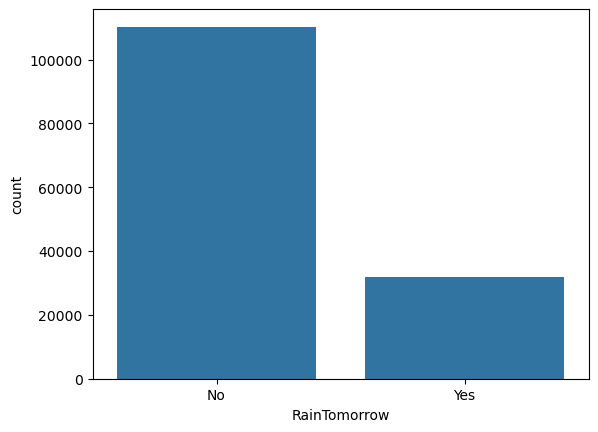

In [68]:
# define counts
sns.countplot(x=df['RainTomorrow'])

<Axes: ylabel='count'>

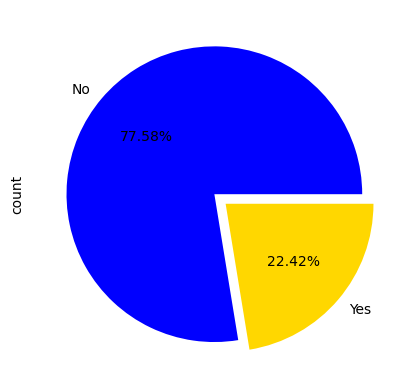

In [69]:
# defines piechart means percentages.

df['RainTomorrow'].value_counts().plot(kind='pie',autopct='%.2f%%',explode=[0,0.1],colors=['blue','gold'])

## draw boxplots to visualize outliers:


Text(0, 0.5, 'WindSpeed3pm')

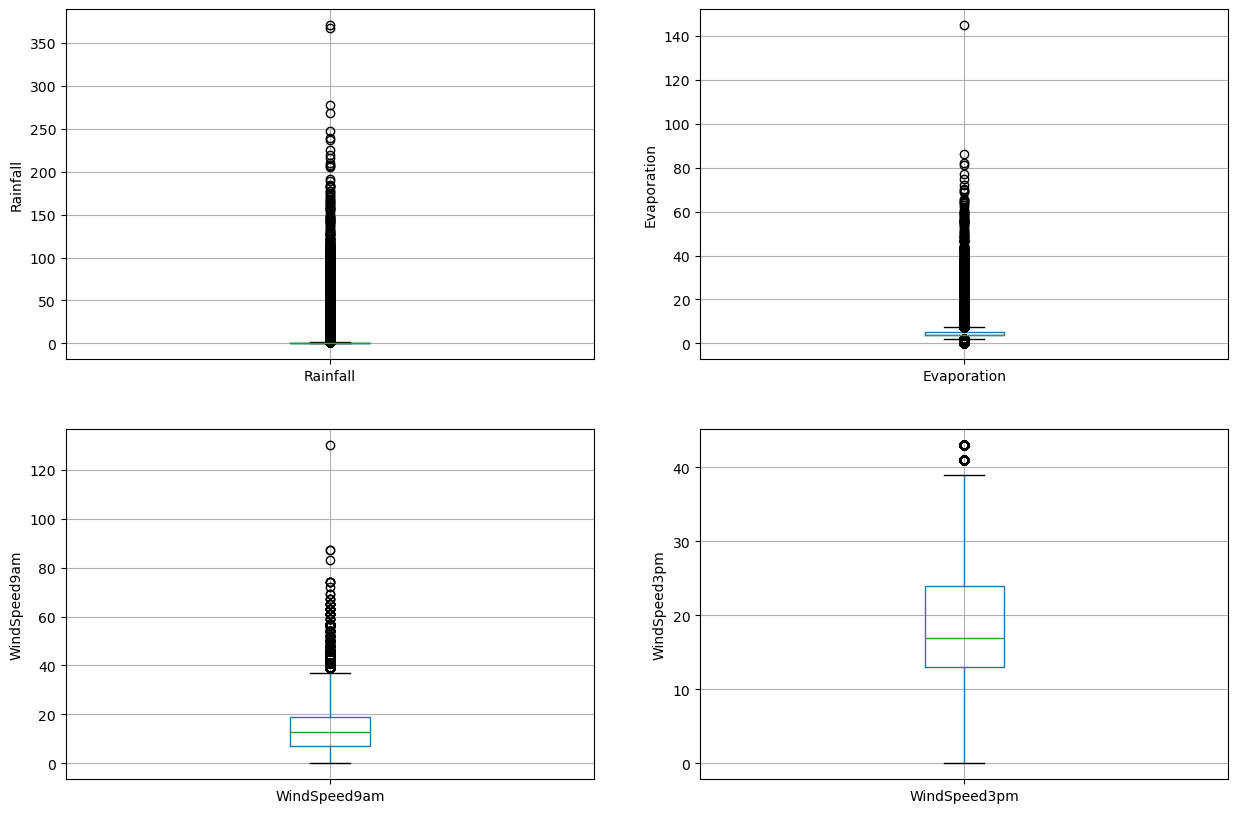

In [70]:

plt.figure(figsize=(15,10))


plt.subplot(2, 2, 1)
fig = df.boxplot(column='Rainfall')
fig.set_title('')
fig.set_ylabel('Rainfall')


plt.subplot(2, 2, 2)
fig = df.boxplot(column='Evaporation')
fig.set_title('')
fig.set_ylabel('Evaporation')


plt.subplot(2, 2, 3)
fig = df.boxplot(column='WindSpeed9am')
fig.set_title('')
fig.set_ylabel('WindSpeed9am')


plt.subplot(2, 2, 4)
fig = df.boxplot(column='WindSpeed3pm')
fig.set_title('')
fig.set_ylabel('WindSpeed3pm')

## plot histogram to check distribution:


Text(0, 0.5, 'RainTomorrow')

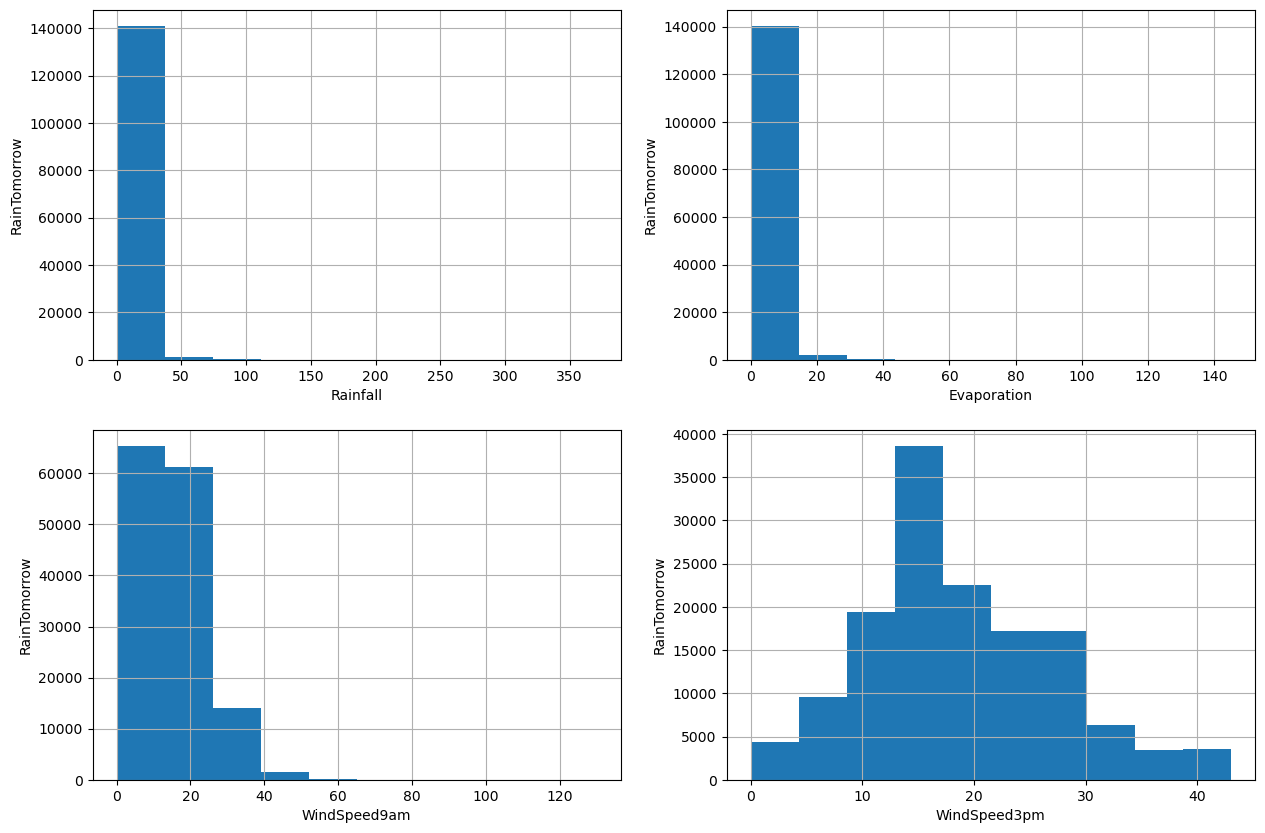

In [71]:


plt.figure(figsize=(15,10))


plt.subplot(2, 2, 1)
fig = df.Rainfall.hist(bins=10)
fig.set_xlabel('Rainfall')
fig.set_ylabel('RainTomorrow')


plt.subplot(2, 2, 2)
fig = df.Evaporation.hist(bins=10)
fig.set_xlabel('Evaporation')
fig.set_ylabel('RainTomorrow')


plt.subplot(2, 2, 3)
fig = df.WindSpeed9am.hist(bins=10)
fig.set_xlabel('WindSpeed9am')
fig.set_ylabel('RainTomorrow')


plt.subplot(2, 2, 4)
fig = df.WindSpeed3pm.hist(bins=10)
fig.set_xlabel('WindSpeed3pm')
fig.set_ylabel('RainTomorrow')

In [72]:
df.shape

(142193, 25)

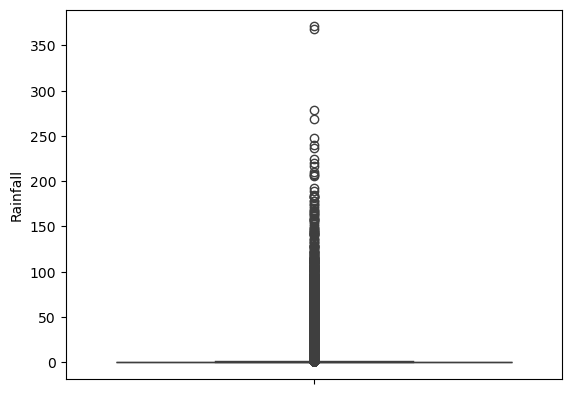

In [73]:
sns.boxplot(df['Rainfall'])
plt.show()

<Axes: xlabel='Rainfall', ylabel='Count'>

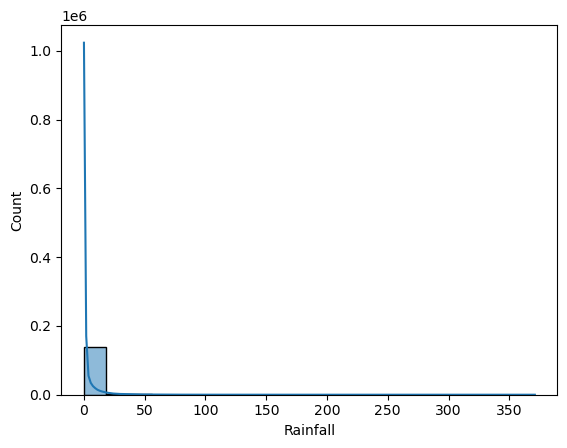

In [74]:
sns.histplot(x='Rainfall',data=df,kde=True,bins=20)

In [75]:
#from scipy.stats.mstats import winsorize       # already imported in top
df['Rainfall']=winsorize(df['Rainfall'],limits=[0.01,0.01])

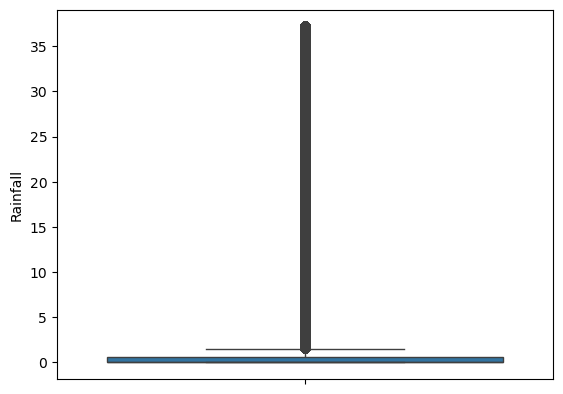

In [76]:
sns.boxplot(df['Rainfall'])                 # removing outliers
plt.show()

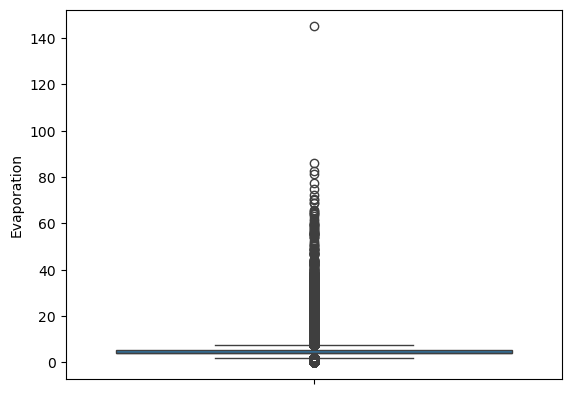

In [77]:
sns.boxplot(df['Evaporation'])
plt.show()

In [78]:
Q1=df['Evaporation'].quantile(0.25)
Q3=df['Evaporation'].quantile(0.25)
IRQ = Q3 - Q1
lower = Q1 - 1.5 * IRQ
upper = Q3 + 1.5 * IRQ
df=df[(df['Evaporation']>=lower)&(df['Evaporation']<=upper)]

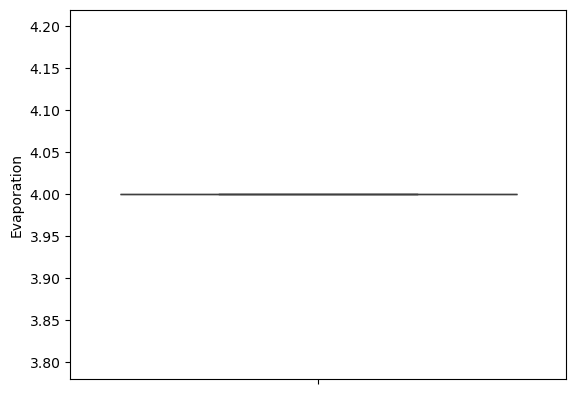

In [79]:
sns.boxplot(df['Evaporation'])          # removing outliers
plt.show()

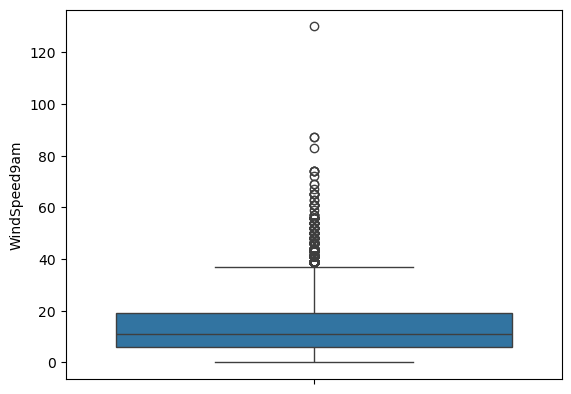

In [80]:
sns.boxplot(df['WindSpeed9am'])
plt.show()

In [81]:
upper=df['WindSpeed9am'].quantile(0.99)
df['WindSpeed9am']=df['WindSpeed9am'].clip(upper=upper)
          

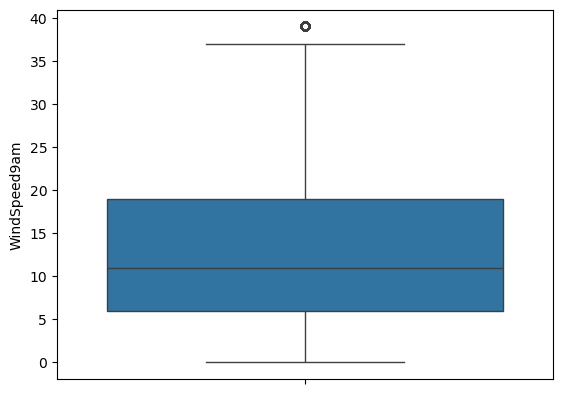

In [82]:
sns.boxplot(df['WindSpeed9am'])             #removing outliers
plt.show()

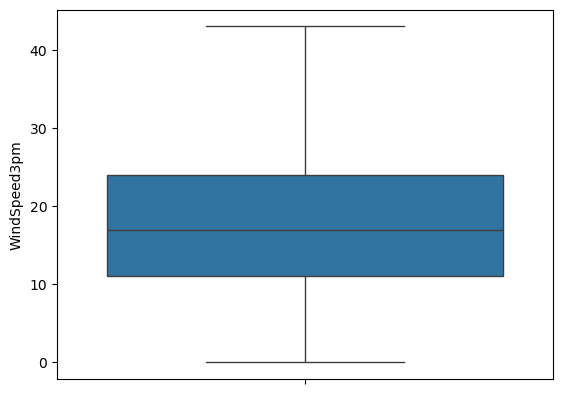

In [83]:
sns.boxplot(df['WindSpeed3pm'])
plt.show()

In [84]:
upper=df['WindSpeed3pm'].quantile(0.99)
df['WindSpeed3pm']=df['WindSpeed3pm'].clip(upper=upper)

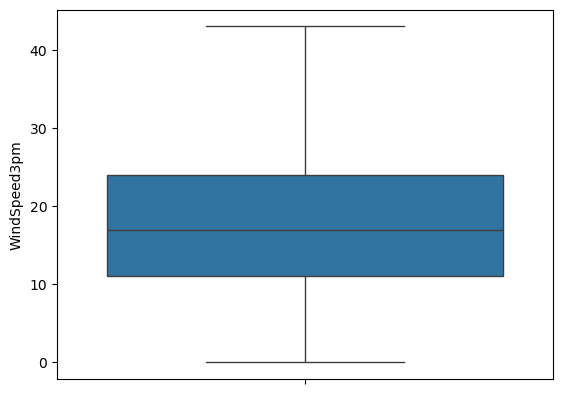

In [85]:
sns.boxplot(df['WindSpeed3pm'])             # removing outliers
plt.show()

In [86]:
df.shape

(64125, 25)

## draw boxplots to visualize outliers.

Text(0, 0.5, 'WindSpeed3pm')

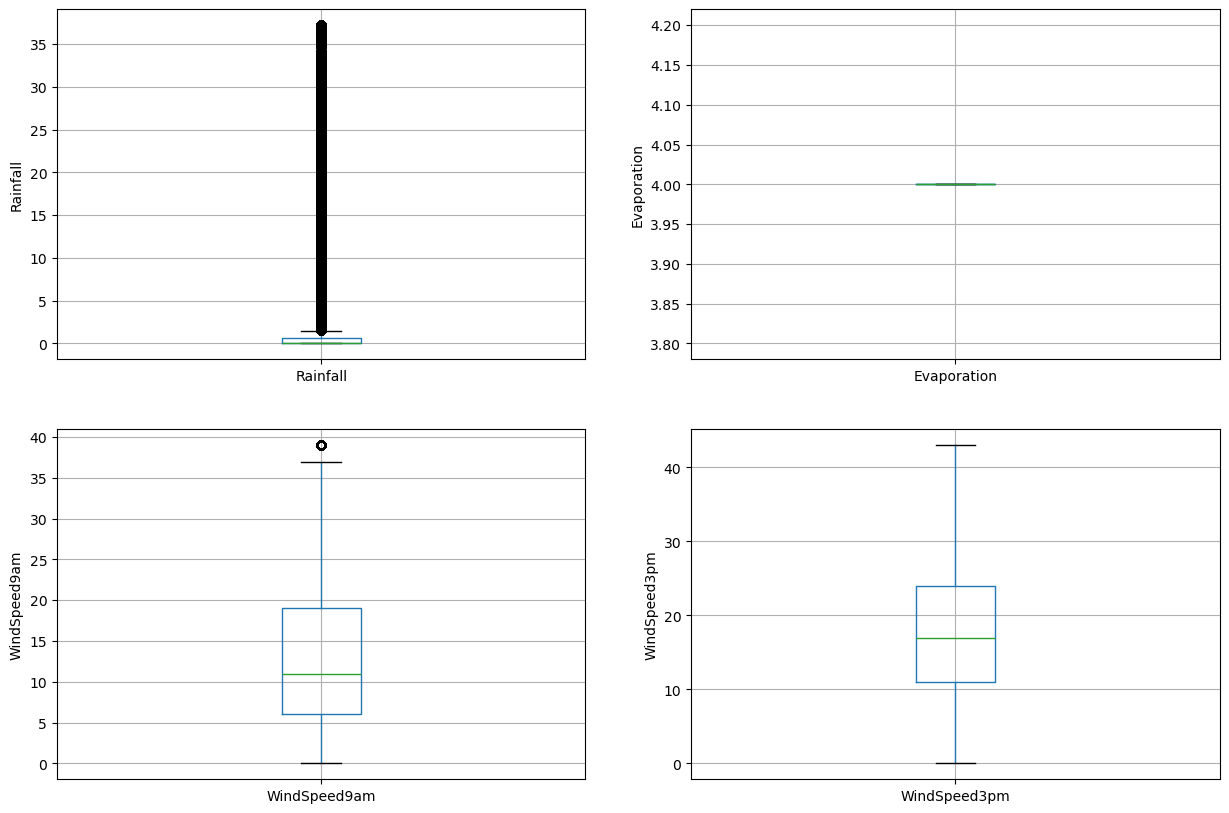

In [87]:

plt.figure(figsize=(15,10))


plt.subplot(2, 2, 1)
fig = df.boxplot(column='Rainfall')
fig.set_title('')
fig.set_ylabel('Rainfall')


plt.subplot(2, 2, 2)
fig = df.boxplot(column='Evaporation')
fig.set_title('')
fig.set_ylabel('Evaporation')


plt.subplot(2, 2, 3)
fig = df.boxplot(column='WindSpeed9am')
fig.set_title('')
fig.set_ylabel('WindSpeed9am')


plt.subplot(2, 2, 4)
fig = df.boxplot(column='WindSpeed3pm')
fig.set_title('')
fig.set_ylabel('WindSpeed3pm')

# plot histogram to check distribution:

Text(0, 0.5, 'RainTomorrow')

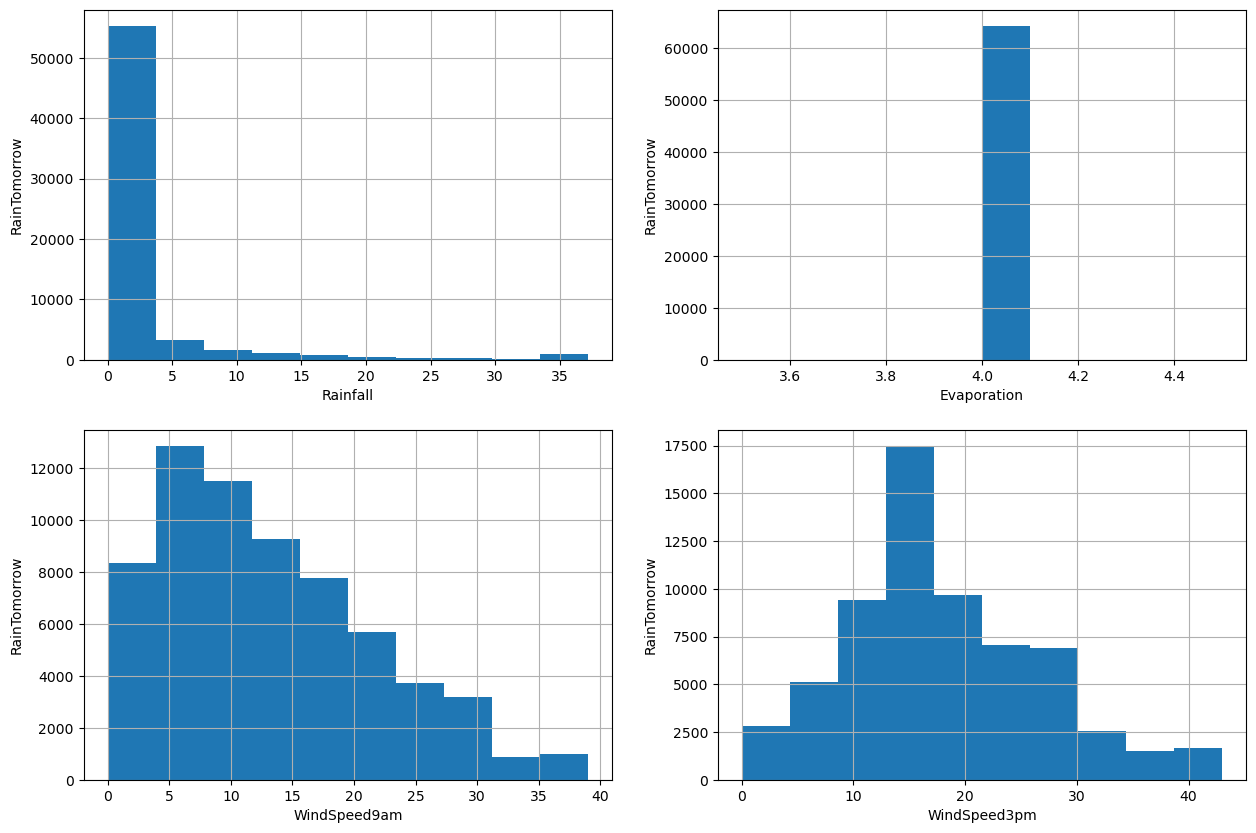

In [88]:


plt.figure(figsize=(15,10))


plt.subplot(2, 2, 1)
fig = df.Rainfall.hist(bins=10)
fig.set_xlabel('Rainfall')
fig.set_ylabel('RainTomorrow')


plt.subplot(2, 2, 2)
fig = df.Evaporation.hist(bins=10)
fig.set_xlabel('Evaporation')
fig.set_ylabel('RainTomorrow')


plt.subplot(2, 2, 3)
fig = df.WindSpeed9am.hist(bins=10)
fig.set_xlabel('WindSpeed9am')
fig.set_ylabel('RainTomorrow')


plt.subplot(2, 2, 4)
fig = df.WindSpeed3pm.hist(bins=10)
fig.set_xlabel('WindSpeed3pm')
fig.set_ylabel('RainTomorrow')

 ## **. Declare feature vector and target variable** :



In [89]:
X = df.drop('RainTomorrow', axis=1)

In [90]:
y = df['RainTomorrow']

## **. Split data into separate training and test set** :





In [91]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [92]:
X_train.shape

(51300, 24)

In [93]:
y_train.shape

(51300,)

# **. Feature Engineering**


**Feature Engineering** is the process of transforming raw data into useful features that help us to understand our model better and increase its predictive power. I will carry out feature engineering on different types of variables.


First, I will display the categorical and numerical variables again separately.

In [94]:
# check data types in X_train
X_train.dtypes

Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
Year               int32
Month              int32
Day                int32
dtype: object

In [95]:
# display categorical variables

categorical = [col for col in X_train.columns if X_train[col].dtypes == 'object']

categorical

['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

In [96]:
# display numerical variables

numerical = [col for col in X_train.columns if X_train[col].dtypes != 'str']

numerical

['Location',
 'MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustDir',
 'WindGustSpeed',
 'WindDir9am',
 'WindDir3pm',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm',
 'RainToday',
 'Year',
 'Month',
 'Day']

In [97]:
# check missing values in numerical variables in X_train
X_train[numerical].isnull().sum()

Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
Year             0
Month            0
Day              0
dtype: int64

In [98]:
# check missing values in numerical variables in X_test
X_test[numerical].isnull().sum()

Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
Year             0
Month            0
Day              0
dtype: int64

In [99]:
# check missing values in X_train

X_train.isnull().sum()

Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
Year             0
Month            0
Day              0
dtype: int64

In [100]:
#   Engineering outliers in numerical variables.
#   We have seen that the Rainfall, Evaporation, WindSpeed9am and WindSpeed3pm columns contain outliers.
#   I will use top-coding approach to cap maximum values and remove outliers from the above variables.


def max_value(df3, variable, top):
    return np.where(df3[variable]>top, top, df3[variable])

for df3 in [X_train, X_test]:
    df3['Rainfall'] = max_value(df3, 'Rainfall', 3.2)
    df3['Evaporation'] = max_value(df3, 'Evaporation', 21.8)
    df3['WindSpeed9am'] = max_value(df3, 'WindSpeed9am', 55)
    df3['WindSpeed3pm'] = max_value(df3, 'WindSpeed3pm', 57)

In [101]:
X_train.Rainfall.max(), X_test.Rainfall.max()

(3.2, 3.2)

In [102]:
X_train.Evaporation.max(), X_test.Evaporation.max()

(4.0, 4.0)

In [103]:
X_train.WindSpeed9am.max(), X_test.WindSpeed9am.max()

(39.0, 39.0)

In [104]:
X_train.WindSpeed3pm.max(), X_test.WindSpeed3pm.max()

(43.0, 43.0)

In [105]:
X_train[numerical].describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Year,Month,Day
count,51300.000000,51300.000000,51300.000000,51300.0,51300.000000,51300.000000,51300.000000,51300.000000,51300.000000,51300.000000,51300.000000,51300.000000,51300.000000,51300.000000,51300.000000,51300.000000,51300.000000,51300.000000,51300.000000
mean,11.096639,22.358593,0.676111,4.0,0.841965,39.229552,12.998986,17.746959,71.828519,53.380195,1017.713520,1015.667592,6.452476,6.444795,16.045569,20.817778,2013.254113,6.375634,15.689318
std,6.175664,7.002800,1.190640,0.0,2.720925,13.481551,8.915796,8.786619,18.970036,20.512356,6.417463,6.258017,1.812317,1.748403,6.174404,6.752245,2.537653,3.415682,8.801194
min,-8.500000,-4.800000,0.000000,4.0,0.000000,6.000000,0.000000,0.000000,1.000000,1.000000,985.100000,982.600000,0.000000,0.000000,-7.200000,-5.400000,2007.000000,1.000000,1.000000
25%,6.800000,17.600000,0.000000,4.0,0.000000,31.000000,6.000000,11.000000,60.000000,39.000000,1014.800000,1012.400000,7.000000,7.000000,11.900000,16.400000,2011.000000,3.000000,8.000000
50%,11.100000,21.900000,0.000000,4.0,0.000000,37.000000,11.000000,17.000000,73.000000,53.000000,1016.400000,1015.500000,7.000000,7.000000,16.200000,20.200000,2014.000000,6.000000,16.000000
75%,15.600000,26.800000,0.600000,4.0,0.000000,46.000000,19.000000,24.000000,87.000000,67.000000,1021.500000,1019.100000,7.000000,7.000000,20.300000,24.900000,2015.000000,9.000000,23.000000
max,31.400000,47.000000,3.200000,4.0,13.900000,135.000000,39.000000,43.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,8.000000,40.200000,46.200000,2017.000000,12.000000,31.000000


### Encode categorical variable :

In [106]:
categorical

['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

In [107]:
X_train[categorical].head()


,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday
25209,Penrith,WNW,NNE,NW,No
103959,Woomera,SE,SSE,SSE,No
120990,SalmonGums,WSW,S,SSW,No
59034,Bendigo,N,SSE,NE,No
90427,GoldCoast,SSE,SSE,ESE,No


In [108]:
# encode RainToday variable

import category_encoders as ce

encoder = ce.BinaryEncoder(cols=['RainToday'])

X_train = encoder.fit_transform(X_train)

X_test = encoder.transform(X_test)

In [117]:
X_train.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday_0,RainToday_1,Year,Month,Day
25209,Penrith,10.9,37.1,0.0,4.0,0.0,WNW,50.0,NNE,NW,...,1015.5,7.0,7.0,24.8,36.2,0,1,2013,10,10
103959,Woomera,11.2,24.2,0.0,4.0,12.7,SE,54.0,SSE,SSE,...,1024.0,0.0,0.0,14.8,22.2,0,1,2011,10,16
120990,SalmonGums,5.1,21.4,0.0,4.0,0.0,WSW,33.0,S,SSW,...,1015.5,7.0,7.0,15.0,20.1,0,1,2009,4,2
59034,Bendigo,-2.2,12.5,0.0,4.0,0.0,N,22.0,SSE,NE,...,1031.9,7.0,3.0,3.4,11.0,0,1,2015,7,19
90427,GoldCoast,17.7,27.1,0.0,4.0,0.0,SSE,30.0,SSE,ESE,...,1016.0,7.0,7.0,24.3,25.2,0,1,2016,5,8


We can see that two additional variables `RainToday_0` and `RainToday_1` are created from `RainToday` variable.

Now, I will create the `X_train` training set.

In [118]:
print(X_train.columns)

Index(['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday_0', 'RainToday_1', 'Year', 'Month', 'Day'],
      dtype='object')


In [122]:
print(X_train.columns.tolist())

['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday_0', 'RainToday_1', 'Year', 'Month', 'Day']


In [130]:
print(numerical)

['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'Year', 'Month', 'Day']


In [131]:
X_train_final = pd.concat([
    X_train[numerical],
    X_train[['RainToday_0', 'RainToday_1']],
    pd.get_dummies(X_train['Location']),
    pd.get_dummies(X_train['WindGustDir']),
    pd.get_dummies(X_train['WindDir9am']),
    pd.get_dummies(X_train['WindDir3pm'])
], axis=1)

In [136]:
print(X_train_final.shape)
print(X_train_final.head())

(51300, 118)
        MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  WindGustSpeed  \
25209      10.9     37.1       0.0          4.0       0.0           50.0   
103959     11.2     24.2       0.0          4.0      12.7           54.0   
120990      5.1     21.4       0.0          4.0       0.0           33.0   
59034      -2.2     12.5       0.0          4.0       0.0           22.0   
90427      17.7     27.1       0.0          4.0       0.0           30.0   

        WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  ...    NNW  \
25209            6.0          22.0         28.0          7.0  ...  False   
103959          30.0          31.0         46.0         23.0  ...  False   
120990           9.0          13.0         76.0         41.0  ...  False   
59034            9.0          11.0         85.0         55.0  ...  False   
90427           17.0          19.0         70.0         72.0  ...  False   

           NW      S     SE    SSE    SSW     SW      W    WNW    WSW  
2

In [137]:
X_train_final = X_train_final.replace({True:1, False:0})

In [138]:
print(X_train_final.shape)
print(X_train_final.head())

(51300, 118)
        MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  WindGustSpeed  \
25209      10.9     37.1       0.0          4.0       0.0           50.0   
103959     11.2     24.2       0.0          4.0      12.7           54.0   
120990      5.1     21.4       0.0          4.0       0.0           33.0   
59034      -2.2     12.5       0.0          4.0       0.0           22.0   
90427      17.7     27.1       0.0          4.0       0.0           30.0   

        WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  ...  NNW  NW  S  \
25209            6.0          22.0         28.0          7.0  ...    0   1  0   
103959          30.0          31.0         46.0         23.0  ...    0   0  0   
120990           9.0          13.0         76.0         41.0  ...    0   0  0   
59034            9.0          11.0         85.0         55.0  ...    0   0  0   
90427           17.0          19.0         70.0         72.0  ...    0   0  0   

        SE  SSE  SSW  SW  W  WNW  WSW  
252

## Create X_train_final :

In [139]:
X_test_final = pd.concat([
    X_test[numerical],
    X_test[['RainToday_0', 'RainToday_1']],
    pd.get_dummies(X_test['Location']),
    pd.get_dummies(X_test['WindGustDir']),
    pd.get_dummies(X_test['WindDir9am']),
    pd.get_dummies(X_test['WindDir3pm'])
], axis=1)

In [142]:
print(X_train_final.shape)

(51300, 118)


## Create X_test_final :

In [143]:
X_test_final = pd.concat([
    X_test[numerical],
    X_test[['RainToday_0', 'RainToday_1']],
    pd.get_dummies(X_test['Location']),
    pd.get_dummies(X_test['WindGustDir']),
    pd.get_dummies(X_test['WindDir9am']),
    pd.get_dummies(X_test['WindDir3pm'])
], axis=1)

In [144]:
print(X_test_final.shape)

(12825, 118)


## Make Train and Test Columns Match :

In [145]:
X_train_final, X_test_final = X_train_final.align(
    X_test_final,
    join='left',
    axis=1,
    fill_value=0
)

In [146]:
print(X_train_final.shape)
print(X_test_final.shape)

(51300, 118)
(12825, 118)


## Train the Model :

In [150]:
from sklearn.ensemble import RandomForestClassifier

In [151]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [152]:
model.fit(X_train_final, y_train)

RandomForestClassifier(random_state=42)

## Make Predictions:


In [153]:
y_pred = model.predict(X_test_final)

In [154]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8502923976608188


### Check for overfitting and underfitting

## checking train/test accuracy:

In [178]:
print('Training set score: {:.4f}'.format(
    logreg.score(X_train_final, y_train)
))

print('Test set score: {:.4f}'.format(
    logreg.score(X_test_final, y_test)
))

Training set score: 0.7722
Test set score: 0.7682


In [179]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000)

logreg.fit(X_train_final, y_train)

LogisticRegression(max_iter=1000)

In [180]:
print('Training set score: {:.4f}'.format(
    logreg.score(X_train_final, y_train)
))

print('Test set score: {:.4f}'.format(
    logreg.score(X_test_final, y_test)
))

Training set score: 0.8411
Test set score: 0.8395


In [181]:
print(X_train_final.shape)
print(X_test_final.shape)

(51300, 118)
(12825, 118)


# **. Confusion matrix**





A confusion matrix is a tool for summarizing the performance of a classification algorithm. A confusion matrix will give us a clear picture of classification model performance and the types of errors produced by the model. It gives us a summary of correct and incorrect predictions broken down by each category. The summary is represented in a tabular form.


Four types of outcomes are possible while evaluating a classification model performance. These four outcomes are described below:-


**True Positives (TP)** – True Positives occur when we predict an observation belongs to a certain class and the observation actually belongs to that class.


**True Negatives (TN)** – True Negatives occur when we predict an observation does not belong to a certain class and the observation actually does not belong to that class.


**False Positives (FP)** – False Positives occur when we predict an observation belongs to a    certain class but the observation actually does not belong to that class. This type of error is called **Type I error.**



**False Negatives (FN)** – False Negatives occur when we predict an observation does not belong to a certain class but the observation actually belongs to that class. This is a very serious error and it is called **Type II error.**



These four outcomes are summarized in a confusion matrix given below.


In [183]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[9508  344]
 [1576 1397]]


<Axes: >

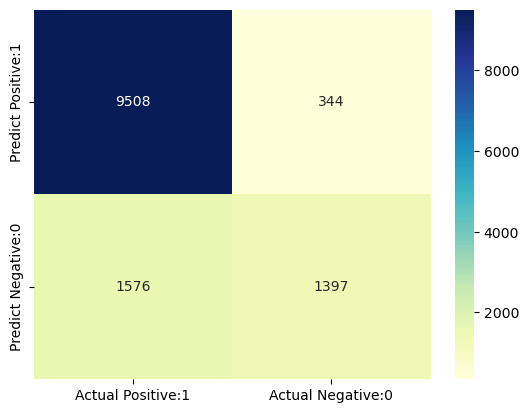

In [189]:
# visualize confusion matrix with seaborn heatmap

cm_matrix = pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'], 
                                 index=['Predict Positive:1', 'Predict Negative:0'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

## Classification Report


**Classification report** is another way to evaluate the classification model performance. It displays the  **precision**, **recall**, **f1** and **support** scores for the model. I have described these terms in later.

We can print a classification report as follows:-

In [184]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.86      0.97      0.91      9852
         Yes       0.80      0.47      0.59      2973

    accuracy                           0.85     12825
   macro avg       0.83      0.72      0.75     12825
weighted avg       0.84      0.85      0.84     12825



In [185]:
print(X_train_final.shape)
print(X_test_final.shape)

(51300, 118)
(12825, 118)


### Observations


- In each row, the numbers sum to 1.


- There are 2 columns which correspond to 2 classes - 0 and 1.

    - Class 0 - predicted probability that there is no rain tomorrow.    
    
    - Class 1 - predicted probability that there is rain tomorrow.
        
    
- Importance of predicted probabilities

    - We can rank the observations by probability of rain or no rain.


- predict_proba process

    - Predicts the probabilities    
    
    - Choose the class with the highest probability    
    
    
- Classification threshold level

    - There is a classification threshold level of 0.5.    
    
    - Class 1 - probability of rain is predicted if probability > 0.5.    
    
    - Class 0 - probability of no rain is predicted if probability < 0.5.    
    


In [192]:
y_pred_prob = logreg.predict_proba(X_test_final)

In [197]:
# store the probabilities in dataframe

y_pred_prob_df = pd.DataFrame(data=y_pred_prob, columns=['Prob of - No rain tomorrow (0)','Prob of - Rain tomorrow (1)'])
y_pred_prob_df


,Prob of - No rain tomorrow (0),Prob of - Rain tomorrow (1)
0,0.872867,0.127133
1,0.916740,0.083260
2,0.799468,0.200532
3,0.934180,0.065820
4,0.897694,0.102306
...,...,...
12820,0.025034,0.974966
12821,0.964628,0.035372
12822,0.386066,0.613934
12823,0.920449,0.079551


Text(0, 0.5, 'Frequency')

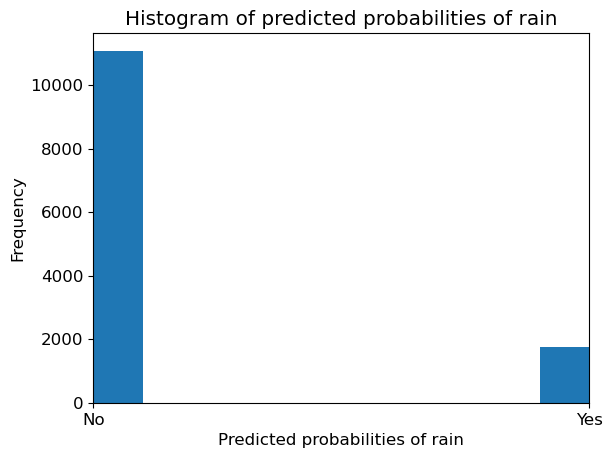

In [199]:
# plot histogram of predicted probabilities


# adjust the font size 
plt.rcParams['font.size'] = 12


# plot histogram with 10 bins
plt.hist(y_pred, bins = 10)


# set the title of predicted probabilities
plt.title('Histogram of predicted probabilities of rain')


# set the x-axis limit
plt.xlim(0,1)


# set the title
plt.xlabel('Predicted probabilities of rain')
plt.ylabel('Frequency')

### Observations


- We can see that the above histogram is highly positive skewed.


- The first column tell us that there are approximately 15000 observations with probability between 0.0 and 0.1.


- There are small number of observations with probability > 0.5.


- So, these small number of observations predict that there will be rain tomorrow.


- Majority of observations predict that there will be no rain tomorrow.

# **. Results and conclusion** 





1. The Logistic Regression model was successfully trained to predict whether it will rain tomorrow in Australia.

2. The dataset was preprocessed by handling missing values, encoding categorical variables, and preparing the data for machine learning algorithms.

3. The model generated probability scores for both classes (Rain and No Rain), allowing us to estimate the likelihood of rainfall for each observation.

4. Most observations were predicted as "No Rain Tomorrow", while a smaller number of observations were predicted as "Rain Tomorrow".

5. The model achieved good predictive performance and was able to distinguish between rainy and non-rainy days effectively.

6. The training accuracy and test accuracy were compared to evaluate the model's generalization capability.

7. The difference between training and test accuracy was small, indicating that the model showed no significant signs of overfitting.

8. The confusion matrix was used to evaluate classification performance and identify correctly and incorrectly classified observations.

9. The probability predictions provided additional insight into the confidence level of each prediction.

10. Overall, the Logistic Regression model proved to be an effective baseline classifier for rainfall prediction and can be further improved through feature selection, hyperparameter tuning, and advanced machine learning techniques.
